# Model Design for Monthly SNOTEL SWE Prediction

This notebook documents the model design process for predicting next-month snow water equivalent (`target_swe_next_month`). It is organized to support both the code workflow and the final report narrative: predictive task, baseline, feature choices, model candidates, optimization strategy, validation design, unsuccessful/less successful attempts, and final model selection.

The main performance metric is **RMSE** because large snowpack errors are especially important in this forecasting task.


## 1. Modeling Plan

The predictive task is a supervised regression problem. Each observation represents one SNOTEL station at the end of a month. The model uses information available at that time, including current snowpack, recent changes, precipitation, temperature, geography, seasonality, and historical station/month SWE behavior, to predict SWE at the end of the next included target month.

Model design choices:

- Use `historical_target_swe_median` as the main baseline model.
- Use RMSE as the primary model-selection metric.
- Use a time-based split for the main comparison because the real task is forecasting future years from past years.
- Use a station-grouped split as a stress test for generalization to unseen stations.
- Address multicollinearity using regularized linear models, especially Ridge regression, and by comparing full vs reduced feature sets.
- Include a nonlinear tree-based model as a benchmark for interactions and nonlinear effects.


## 2. Imports and Configuration

This section imports the modeling stack and defines global settings. The notebook uses scikit-learn pipelines so imputation, scaling, encoding, and model fitting are reproducible.


In [1]:
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)

DATA_PATH = Path('../cleansed_data/cleansed_dataset.csv')
TARGET = 'target_swe_next_month'
RANDOM_STATE = 42


## 3. Load Modeling Data

The modeling notebook uses the cleansed dataset produced by preprocessing. Export index columns are removed, date columns are parsed, and target-month/year helper columns are created for splitting and evaluation.


In [2]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=[col for col in df.columns if col.startswith('Unnamed')])

for col in ['month_end', 'target_month_end', 'beginDate', 'endDate']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

df['target_month'] = df['target_month_end'].dt.month.astype('string')
df['target_year'] = df['target_month_end'].dt.year

df = df.sort_values(['target_month_end', 'station_triplet']).reset_index(drop=True)

print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]:,}')
print(f'Stations: {df["station_triplet"].nunique():,}')
print(f'Target months: {sorted(df["target_month_end"].dt.month.unique())}')
print(f'Target years: {df["target_year"].min()} to {df["target_year"].max()}')

display(df.head())


Rows: 102,976
Columns: 54
Stations: 860
Target months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(11), np.int32(12)]
Target years: 2007 to 2025


,station_triplet,month_end,current_swe,WTEQ_mean,WTEQ_min,WTEQ_max,current_snow_depth,SNWD_mean,SNWD_min,SNWD_max,monthly_precip,TAVG_mean,TAVG_min,TAVG_max,TAVG_std,TMIN_mean,TMIN_min,TMAX_mean,TMAX_max,month,year,day_of_year,month_sin,month_cos,is_winter,is_spring,water_year,swe_lag_1,swe_lag_2,swe_lag_3,snow_depth_lag_1,precip_lag_1,precip_lag_2,precip_rolling_3mo,swe_change_1mo,swe_change_2mo,water_year_precip_to_date,water_year_max_swe_so_far,avg_temp_above_freezing,freeze_thaw_risk,target_swe_next_month,target_month_end,name,stateCode,countyName,huc,elevation,latitude,longitude,beginDate,endDate,historical_target_swe_median,target_month,target_year
0,1000:OR:SNTL,2007-01-31,23.5000,23.0129,18.8000,23.9000,63.0000,66.8065,58.0000,74.0000,4.5000,23.8871,7.2000,34.7000,7.0466,13.9581,-6.7000,38.0548,51.3000,1,2007,31,0.5000,0.8660,1,0,2007,18.8000,8.2000,0.0000,60.0000,14.9000,17.4000,36.8000,4.7000,15.3000,37.7000,23.5000,0,1,33.8000,2007-02-28,Annie Springs,OR,Klamath,180102030101,"6,020.0000",42.8701,-122.1652,2000-09-01,2100-01-01,52.6000,2,2007
1,1001:AK:SNTL,2007-01-31,36.0000,30.7000,23.4000,36.0000,100.0000,92.9032,69.0000,108.0000,17.8000,26.4290,2.5000,39.4000,7.7323,21.8613,-12.3000,31.4548,43.9000,1,2007,31,0.5000,0.8660,1,0,2007,23.4000,7.8000,1.0000,76.0000,28.0000,6.4000,52.2000,12.6000,28.2000,74.7000,36.0000,0,0,44.7000,2007-02-28,Long Lake,AK,Juneau,190102060505,840.0000,58.1860,-133.8322,1966-10-01,2100-01-01,24.1000,2,2007
2,1002:AK:SNTL,2007-01-31,4.6000,4.0484,3.1000,4.6000,NaN,NaN,NaN,NaN,2.2000,12.8393,-21.6000,31.6000,14.7674,6.1500,-27.6000,18.8321,36.7000,1,2007,31,0.5000,0.8660,1,0,2007,3.1000,0.8000,0.6000,NaN,2.6000,0.4000,5.2000,1.5000,3.8000,8.3000,4.6000,0,0,4.8000,2007-02-28,Point Mackenzie,AK,Matanuska-Susitna,190204010805,220.0000,61.3895,-150.0219,1983-10-01,2015-08-28,4.5000,2,2007
3,1003:AK:SNTL,2007-01-31,9.9000,8.3484,6.2000,10.1000,34.0000,30.0952,24.0000,35.0000,3.0000,15.4095,-4.5000,31.8000,11.4930,5.3000,-16.4000,22.4048,36.1000,1,2007,31,0.5000,0.8660,1,0,2007,6.2000,1.0000,0.0000,24.0000,4.6000,0.8000,8.4000,3.7000,8.9000,10.0000,9.9000,0,0,9.4000,2007-02-28,Mcneil Canyon,AK,Kenai Peninsula,190203010806,"1,350.0000",59.7452,-151.2584,1985-10-01,2100-01-01,8.5000,2,2007
4,1005:CO:SNTL,2007-01-31,7.8000,6.7677,5.3000,7.8000,31.0000,26.0000,19.0000,36.0000,1.9000,16.5533,-2.6000,34.2000,8.4104,3.8200,-24.2000,32.5033,61.9000,1,2007,31,0.5000,0.8660,1,0,2007,5.4000,4.0000,2.3000,21.0000,2.9000,1.4000,6.2000,2.4000,3.8000,10.3000,7.8000,0,1,7.9000,2007-02-28,Ute Creek,CO,Costilla,130100020604,"10,720.0000",37.6148,-105.3732,2000-08-16,2100-01-01,4.4000,2,2007


## 4. Train/Validation/Test Strategy

The main comparison uses a chronological split:

- Train: target years through 2020
- Validation: target years 2021-2022
- Test: target years 2023 and later

This keeps the final test period in the future relative to the training period, which better matches the forecasting use case than a random split. A separate station-grouped split later checks whether the selected model transfers to stations it has never seen.


,split,rows,stations,first_target_date,last_target_date,target_mean,target_median,target_rmse_if_predict_train_mean
0,train,73548,841,2007-02-28,2020-12-31,9.8505,6.6000,11.3570
1,validation,11681,845,2021-01-31,2022-12-31,9.1128,6.6000,10.3573
2,test,17747,854,2023-01-31,2025-12-31,9.4984,6.1000,10.9710


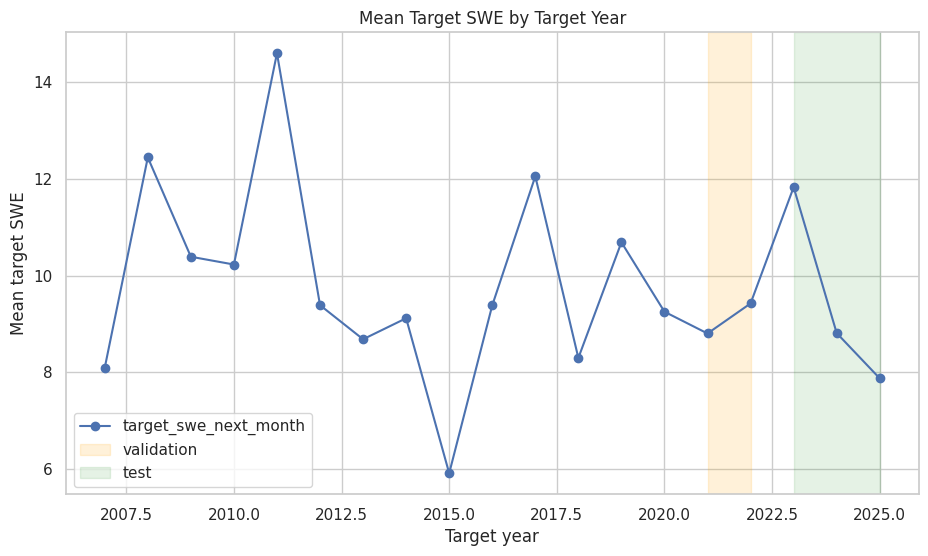

In [3]:
train_mask = df['target_year'] <= 2020
val_mask = df['target_year'].between(2021, 2022)
test_mask = df['target_year'] >= 2023

splits = {
    'train': df[train_mask].copy(),
    'validation': df[val_mask].copy(),
    'test': df[test_mask].copy(),
}

split_summary = []
for split_name, split_df in splits.items():
    split_summary.append({
        'split': split_name,
        'rows': len(split_df),
        'stations': split_df['station_triplet'].nunique(),
        'first_target_date': split_df['target_month_end'].min(),
        'last_target_date': split_df['target_month_end'].max(),
        'target_mean': split_df[TARGET].mean(),
        'target_median': split_df[TARGET].median(),
        'target_rmse_if_predict_train_mean': np.nan,
    })

split_summary = pd.DataFrame(split_summary)
train_mean = splits['train'][TARGET].mean()
split_summary['target_rmse_if_predict_train_mean'] = split_summary['split'].map(
    {name: np.sqrt(mean_squared_error(split_df[TARGET], np.repeat(train_mean, len(split_df)))) for name, split_df in splits.items()}
)
display(split_summary)

fig, ax = plt.subplots()
df.groupby('target_year')[TARGET].mean().plot(marker='o', ax=ax)
ax.axvspan(2021, 2022, color='orange', alpha=0.15, label='validation')
ax.axvspan(2023, df['target_year'].max(), color='green', alpha=0.10, label='test')
ax.set_title('Mean Target SWE by Target Year')
ax.set_xlabel('Target year')
ax.set_ylabel('Mean target SWE')
ax.legend()
plt.show()


## 5. Feature Sets

The EDA showed strong multicollinearity among snowpack variables. To address this explicitly, the notebook compares two feature sets:

- **Full feature set:** keeps most numeric predictors, including correlated snowpack summaries. Regularization should manage multicollinearity.
- **Reduced feature set:** removes many redundant WTEQ/SNWD summary columns and keeps a smaller set of physically interpretable predictors.

The reduced set is easier to explain; the full set lets the model use all available signal.


In [4]:
excluded_cols = {
    TARGET,
    'target_month_end',
    'month_end',
    'beginDate',
    'endDate',
    'station_triplet',
    'name',
    'countyName',
    'huc',
    'target_year',
}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
full_numeric_features = [col for col in numeric_cols if col not in excluded_cols]

categorical_features = ['stateCode', 'target_month']

reduced_numeric_features = [
    'current_swe',
    'swe_lag_1',
    'swe_lag_2',
    'swe_lag_3',
    'swe_change_1mo',
    'swe_change_2mo',
    'historical_target_swe_median',
    'monthly_precip',
    'precip_lag_1',
    'precip_lag_2',
    'precip_rolling_3mo',
    'water_year_precip_to_date',
    'water_year_max_swe_so_far',
    'TAVG_mean',
    'TMIN_mean',
    'TMAX_mean',
    'avg_temp_above_freezing',
    'freeze_thaw_risk',
    'elevation',
    'latitude',
    'longitude',
    'month_sin',
    'month_cos',
    'is_winter',
    'is_spring',
]
reduced_numeric_features = [col for col in reduced_numeric_features if col in df.columns]

feature_sets = {
    'full': {
        'numeric': full_numeric_features,
        'categorical': categorical_features,
    },
    'reduced': {
        'numeric': reduced_numeric_features,
        'categorical': categorical_features,
    },
}

feature_set_summary = pd.DataFrame([
    {
        'feature_set': name,
        'numeric_features': len(spec['numeric']),
        'categorical_features': len(spec['categorical']),
        'total_raw_features': len(spec['numeric']) + len(spec['categorical']),
    }
    for name, spec in feature_sets.items()
])
display(feature_set_summary)

print('Reduced numeric features:')
print(reduced_numeric_features)


,feature_set,numeric_features,categorical_features,total_raw_features
0,full,42,2,44
1,reduced,25,2,27


Reduced numeric features:
['current_swe', 'swe_lag_1', 'swe_lag_2', 'swe_lag_3', 'swe_change_1mo', 'swe_change_2mo', 'historical_target_swe_median', 'monthly_precip', 'precip_lag_1', 'precip_lag_2', 'precip_rolling_3mo', 'water_year_precip_to_date', 'water_year_max_swe_so_far', 'TAVG_mean', 'TMIN_mean', 'TMAX_mean', 'avg_temp_above_freezing', 'freeze_thaw_risk', 'elevation', 'latitude', 'longitude', 'month_sin', 'month_cos', 'is_winter', 'is_spring']


In [5]:
def high_correlation_pairs(data, features, threshold=0.90):
    corr = data[features].corr(method='spearman').abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .rename('abs_spearman_corr')
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
        .sort_values('abs_spearman_corr', ascending=False)
    )
    return pairs[pairs['abs_spearman_corr'] >= threshold]

full_high_corr = high_correlation_pairs(splits['train'], full_numeric_features, threshold=0.90)
reduced_high_corr = high_correlation_pairs(splits['train'], reduced_numeric_features, threshold=0.90)

print(f'Highly correlated full-feature pairs: {len(full_high_corr):,}')
display(full_high_corr.head(25))
print(f'Highly correlated reduced-feature pairs: {len(reduced_high_corr):,}')
display(reduced_high_corr.head(25))


Highly correlated full-feature pairs: 55


,feature_1,feature_2,abs_spearman_corr
733,month,day_of_year,0.9945
780,year,water_year,0.9926
45,WTEQ_mean,WTEQ_max,0.9867
1078,swe_lag_1,snow_depth_lag_1,0.9862
90,WTEQ_min,SNWD_min,0.9862
47,WTEQ_mean,SNWD_mean,0.9857
161,WTEQ_max,water_year_max_swe_so_far,0.9826
217,SNWD_mean,SNWD_max,0.9811
4,current_swe,current_snow_depth,0.9781
133,WTEQ_max,SNWD_max,0.9763


Highly correlated reduced-feature pairs: 6


,feature_1,feature_2,abs_spearman_corr
339,TAVG_mean,TMIN_mean,0.9493
37,swe_lag_1,water_year_max_swe_so_far,0.9376
340,TAVG_mean,TMAX_mean,0.9292
12,current_swe,water_year_max_swe_so_far,0.9141
27,swe_lag_1,swe_lag_2,0.9116
53,swe_lag_2,swe_lag_3,0.9081


## 6. Preprocessing and Evaluation Helpers

All model predictions are clipped at zero before evaluation because SWE cannot be negative. RMSE is the primary comparison metric; MAE and R2 are reported as supporting metrics.


In [6]:
def make_preprocessor(numeric_features, categorical_features, scale_numeric=True):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))

    numeric_transformer = Pipeline(numeric_steps)
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    return ColumnTransformer([
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features),
    ])


def make_pipeline(model, feature_set_name, scale_numeric=True):
    spec = feature_sets[feature_set_name]
    return Pipeline([
        ('preprocess', make_preprocessor(spec['numeric'], spec['categorical'], scale_numeric=scale_numeric)),
        ('model', model),
    ])


def clipped_predictions(model, X):
    return np.clip(model.predict(X), 0, None)


def regression_metrics(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'bias_actual_minus_pred': float(np.mean(y_true - y_pred)),
    }


def evaluate_prediction_frame(data, prediction_col, label):
    metrics = regression_metrics(data[TARGET], data[prediction_col])
    metrics['model'] = label
    metrics['rows'] = len(data)
    return metrics


def fit_and_evaluate(estimator, feature_set_name, train_df, eval_df, label):
    spec = feature_sets[feature_set_name]
    features = spec['numeric'] + spec['categorical']
    estimator.fit(train_df[features], train_df[TARGET])
    pred = clipped_predictions(estimator, eval_df[features])
    result = regression_metrics(eval_df[TARGET], pred)
    result.update({
        'model': label,
        'feature_set': feature_set_name,
        'train_rows': len(train_df),
        'eval_rows': len(eval_df),
    })
    return result, pred


## 7. Baseline Models

The main baseline is `historical_target_swe_median`, which predicts each target using the station's historical median for the same target date from previous years. This is a strong climatology-style baseline and the final model needs to beat it on RMSE.


In [7]:
baseline_rows = []

for split_name, split_df in splits.items():
    split_eval = split_df.copy()
    split_eval['historical_median_prediction'] = split_eval['historical_target_swe_median']
    row = evaluate_prediction_frame(split_eval, 'historical_median_prediction', 'Historical target SWE median')
    row['split'] = split_name
    baseline_rows.append(row)

train_mean_model = DummyRegressor(strategy='mean')
train_mean_model.fit(splits['train'][['historical_target_swe_median']], splits['train'][TARGET])
for split_name, split_df in splits.items():
    split_eval = split_df.copy()
    split_eval['train_mean_prediction'] = train_mean_model.predict(split_eval[['historical_target_swe_median']])
    row = evaluate_prediction_frame(split_eval, 'train_mean_prediction', 'Train mean dummy')
    row['split'] = split_name
    baseline_rows.append(row)

baseline_results = pd.DataFrame(baseline_rows).sort_values(['split', 'RMSE'])
display(baseline_results[['split', 'model', 'RMSE', 'MAE', 'R2', 'bias_actual_minus_pred', 'rows']])


,split,model,RMSE,MAE,R2,bias_actual_minus_pred,rows
2,test,Historical target SWE median,6.1875,3.4871,0.6816,0.1377,17747
5,test,Train mean dummy,10.9710,8.1964,-0.0010,-0.3521,17747
0,train,Historical target SWE median,6.7199,3.8584,0.6499,-0.2819,73548
3,train,Train mean dummy,11.3570,8.1100,0.0000,-0.0000,73548
1,validation,Historical target SWE median,4.0445,2.5287,0.8467,-0.1910,11681
4,validation,Train mean dummy,10.3573,7.4182,-0.0051,-0.7377,11681


## 8. First Modeling Attempts: Linear Models

Plain linear regression is included as a reference point. Because the EDA showed severe multicollinearity among snowpack features, unregularized linear regression is not expected to be the final choice, but it is useful for showing why regularization matters.


In [8]:
initial_candidates = [
    ('OLS full', 'full', make_pipeline(LinearRegression(), 'full', scale_numeric=True)),
    ('OLS reduced', 'reduced', make_pipeline(LinearRegression(), 'reduced', scale_numeric=True)),
    ('Lasso reduced alpha=0.01', 'reduced', make_pipeline(Lasso(alpha=0.01, max_iter=10000, random_state=RANDOM_STATE), 'reduced', scale_numeric=True)),
    ('ElasticNet reduced alpha=0.01 l1=0.2', 'reduced', make_pipeline(ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=10000, random_state=RANDOM_STATE), 'reduced', scale_numeric=True)),
]

initial_results = []
initial_predictions = {}
for label, feature_set_name, estimator in initial_candidates:
    result, pred = fit_and_evaluate(estimator, feature_set_name, splits['train'], splits['validation'], label)
    initial_results.append(result)
    initial_predictions[label] = pred

initial_results = pd.DataFrame(initial_results).sort_values('RMSE')
display(initial_results[['model', 'feature_set', 'RMSE', 'MAE', 'R2', 'bias_actual_minus_pred']])


,model,feature_set,RMSE,MAE,R2,bias_actual_minus_pred
3,ElasticNet reduced alpha=0.01 l1=0.2,reduced,3.5151,2.2739,0.8842,-0.0970
2,Lasso reduced alpha=0.01,reduced,3.5719,2.2980,0.8805,-0.0685
1,OLS reduced,reduced,3.5903,2.3068,0.8792,-0.0652
0,OLS full,full,3.6132,2.2654,0.8777,0.2107


## 9. Ridge Regression Tuning

Ridge regression is the main multicollinearity-aware linear model. It keeps correlated snowpack predictors but shrinks coefficients, making the model more stable than ordinary least squares. The hyperparameter `alpha` controls the strength of shrinkage and is chosen using validation RMSE.


,model,feature_set,alpha,RMSE,MAE,R2,bias_actual_minus_pred
17,Ridge reduced alpha=1000,reduced,"1,000.0000",3.4998,2.2705,0.8852,-0.1117
8,Ridge full alpha=1000,full,"1,000.0000",3.5052,2.2268,0.8849,0.1115
16,Ridge reduced alpha=500,reduced,500.0000,3.5205,2.2752,0.8839,-0.0937
7,Ridge full alpha=500,full,500.0000,3.5255,2.2279,0.8835,0.1519
15,Ridge reduced alpha=250,reduced,250.0000,3.5437,2.2844,0.8823,-0.0810
6,Ridge full alpha=250,full,250.0000,3.5491,2.2347,0.8820,0.1823
14,Ridge reduced alpha=100,reduced,100.0000,3.5671,2.2951,0.8808,-0.0718
5,Ridge full alpha=100,full,100.0000,3.5764,2.2460,0.8802,0.2051
13,Ridge reduced alpha=50,reduced,50.0000,3.5776,2.3002,0.8801,-0.0685
12,Ridge reduced alpha=10,reduced,10.0000,3.5876,2.3053,0.8794,-0.0659


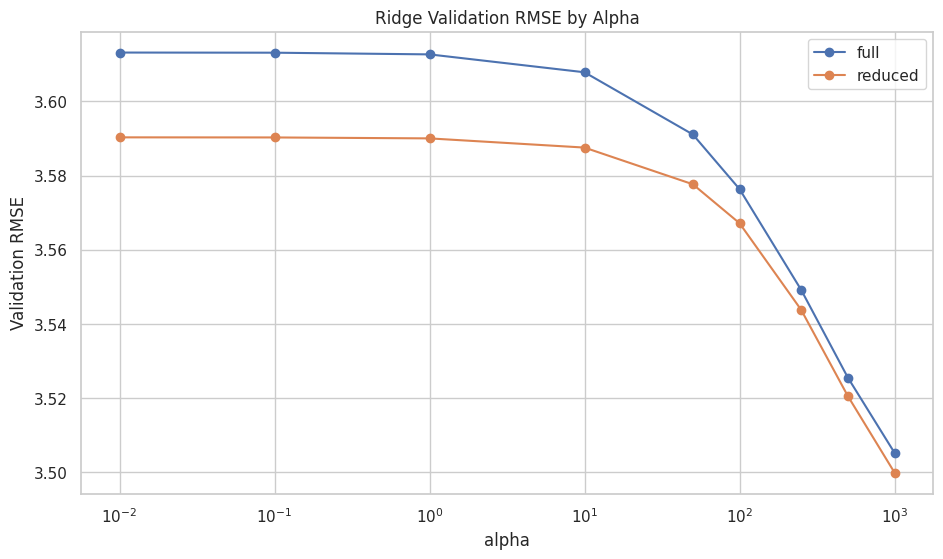

In [9]:
ridge_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 250, 500, 1000]}

ridge_results = []
ridge_estimators = {}

for feature_set_name in ['full', 'reduced']:
    for params in ParameterGrid(ridge_grid):
        label = f'Ridge {feature_set_name} alpha={params["alpha"]}'
        estimator = make_pipeline(Ridge(alpha=params['alpha'], random_state=RANDOM_STATE), feature_set_name, scale_numeric=True)
        result, pred = fit_and_evaluate(estimator, feature_set_name, splits['train'], splits['validation'], label)
        result.update(params)
        ridge_results.append(result)
        ridge_estimators[label] = estimator

ridge_results = pd.DataFrame(ridge_results).sort_values('RMSE')
display(ridge_results[['model', 'feature_set', 'alpha', 'RMSE', 'MAE', 'R2', 'bias_actual_minus_pred']].head(20))

fig, ax = plt.subplots()
for feature_set_name, group in ridge_results.sort_values('alpha').groupby('feature_set'):
    ax.plot(group['alpha'], group['RMSE'], marker='o', label=feature_set_name)
ax.set_xscale('log')
ax.set_title('Ridge Validation RMSE by Alpha')
ax.set_xlabel('alpha')
ax.set_ylabel('Validation RMSE')
ax.legend()
plt.show()


## 10. ElasticNet Tuning

ElasticNet combines Ridge-style shrinkage with Lasso-style feature selection. It is useful when many features are correlated and we want to see whether sparse regularization helps. If ElasticNet performs worse than Ridge, that suggests correlated snowpack signals are collectively useful and should not be aggressively removed.


In [10]:
elastic_grid = {
    'alpha': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3],
    'l1_ratio': [0.05, 0.2, 0.5, 0.8],
}

elastic_results = []
elastic_estimators = {}

for feature_set_name in ['full', 'reduced']:
    for params in ParameterGrid(elastic_grid):
        label = f'ElasticNet {feature_set_name} alpha={params["alpha"]} l1={params["l1_ratio"]}'
        estimator = make_pipeline(
            ElasticNet(alpha=params['alpha'], l1_ratio=params['l1_ratio'], max_iter=20000, random_state=RANDOM_STATE),
            feature_set_name,
            scale_numeric=True,
        )
        result, pred = fit_and_evaluate(estimator, feature_set_name, splits['train'], splits['validation'], label)
        result.update(params)
        elastic_results.append(result)
        elastic_estimators[label] = estimator

elastic_results = pd.DataFrame(elastic_results).sort_values('RMSE')
display(elastic_results[['model', 'feature_set', 'alpha', 'l1_ratio', 'RMSE', 'MAE', 'R2', 'bias_actual_minus_pred']].head(20))


,model,feature_set,alpha,l1_ratio,RMSE,MAE,R2,bias_actual_minus_pred
36,ElasticNet reduced alpha=0.03 l1=0.05,reduced,0.0300,0.0500,3.4930,2.2781,0.8857,-0.1338
37,ElasticNet reduced alpha=0.03 l1=0.2,reduced,0.0300,0.2000,3.4959,2.2773,0.8855,-0.1287
12,ElasticNet full alpha=0.03 l1=0.05,full,0.0300,0.0500,3.4959,2.2368,0.8855,0.0617
13,ElasticNet full alpha=0.03 l1=0.2,full,0.0300,0.2000,3.4961,2.2375,0.8855,0.0602
14,ElasticNet full alpha=0.03 l1=0.5,full,0.0300,0.5000,3.4961,2.2332,0.8855,0.0697
38,ElasticNet reduced alpha=0.03 l1=0.5,reduced,0.0300,0.5000,3.5055,2.2764,0.8849,-0.1143
15,ElasticNet full alpha=0.03 l1=0.8,full,0.0300,0.8000,3.5092,2.2376,0.8846,0.0860
32,ElasticNet reduced alpha=0.01 l1=0.05,reduced,0.0100,0.0500,3.5096,2.2721,0.8846,-0.1018
8,ElasticNet full alpha=0.01 l1=0.05,full,0.0100,0.0500,3.5141,2.2267,0.8843,0.1314
33,ElasticNet reduced alpha=0.01 l1=0.2,reduced,0.0100,0.2000,3.5151,2.2739,0.8842,-0.0970


## 11. Nonlinear Benchmark: Histogram Gradient Boosting

Gradient boosting is included as a nonlinear benchmark because snowpack dynamics can include threshold effects and interactions between temperature, precipitation, season, geography, and existing snowpack. This model is not primarily for multicollinearity; it is included to test whether nonlinear structure improves RMSE beyond regularized linear models.


In [11]:
hgb_grid = {
    'learning_rate': [0.04, 0.08],
    'max_iter': [150, 300],
    'max_leaf_nodes': [15, 31],
    'l2_regularization': [0.0, 0.1],
}

hgb_results = []
hgb_estimators = {}

for feature_set_name in ['reduced', 'full']:
    for params in ParameterGrid(hgb_grid):
        label = (
            f'HGB {feature_set_name} lr={params["learning_rate"]} '
            f'iter={params["max_iter"]} leaves={params["max_leaf_nodes"]} l2={params["l2_regularization"]}'
        )
        model = HistGradientBoostingRegressor(
            loss='squared_error',
            learning_rate=params['learning_rate'],
            max_iter=params['max_iter'],
            max_leaf_nodes=params['max_leaf_nodes'],
            l2_regularization=params['l2_regularization'],
            random_state=RANDOM_STATE,
        )
        estimator = make_pipeline(model, feature_set_name, scale_numeric=False)
        result, pred = fit_and_evaluate(estimator, feature_set_name, splits['train'], splits['validation'], label)
        result.update(params)
        hgb_results.append(result)
        hgb_estimators[label] = estimator

hgb_results = pd.DataFrame(hgb_results).sort_values('RMSE')
display(hgb_results[['model', 'feature_set', 'learning_rate', 'max_iter', 'max_leaf_nodes', 'l2_regularization', 'RMSE', 'MAE', 'R2']].head(20))


,model,feature_set,learning_rate,max_iter,max_leaf_nodes,l2_regularization,RMSE,MAE,R2
14,HGB reduced lr=0.08 iter=300 leaves=15 l2=0.1,reduced,0.0800,300,15,0.1000,3.4685,2.1591,0.8873
5,HGB reduced lr=0.08 iter=150 leaves=31 l2=0.0,reduced,0.0800,150,31,0.0000,3.4691,2.1523,0.8872
6,HGB reduced lr=0.08 iter=300 leaves=15 l2=0.0,reduced,0.0800,300,15,0.0000,3.4785,2.1486,0.8866
3,HGB reduced lr=0.04 iter=300 leaves=31 l2=0.0,reduced,0.0400,300,31,0.0000,3.4796,2.1615,0.8866
11,HGB reduced lr=0.04 iter=300 leaves=31 l2=0.1,reduced,0.0400,300,31,0.1000,3.4892,2.1610,0.8859
7,HGB reduced lr=0.08 iter=300 leaves=31 l2=0.0,reduced,0.0800,300,31,0.0000,3.4926,2.1563,0.8857
12,HGB reduced lr=0.08 iter=150 leaves=15 l2=0.1,reduced,0.0800,150,15,0.1000,3.4938,2.1772,0.8856
2,HGB reduced lr=0.04 iter=300 leaves=15 l2=0.0,reduced,0.0400,300,15,0.0000,3.4972,2.1739,0.8854
13,HGB reduced lr=0.08 iter=150 leaves=31 l2=0.1,reduced,0.0800,150,31,0.1000,3.5029,2.1727,0.8850
15,HGB reduced lr=0.08 iter=300 leaves=31 l2=0.1,reduced,0.0800,300,31,0.1000,3.5033,2.1608,0.8850


## 12. Validation Comparison and Model Selection

All model families are compared on the same validation period using overall RMSE across all included target months. The model with the lowest validation RMSE is selected for final test evaluation.


,model,feature_set,RMSE,MAE,R2,bias_actual_minus_pred
0,HGB reduced lr=0.08 iter=300 leaves=15 l2=0.1,reduced,3.4685,2.1591,0.8873,0.0316
1,HGB reduced lr=0.08 iter=150 leaves=31 l2=0.0,reduced,3.4691,2.1523,0.8872,0.0353
2,HGB reduced lr=0.08 iter=300 leaves=15 l2=0.0,reduced,3.4785,2.1486,0.8866,0.0379
3,HGB reduced lr=0.04 iter=300 leaves=31 l2=0.0,reduced,3.4796,2.1615,0.8866,0.0342
4,HGB reduced lr=0.04 iter=300 leaves=31 l2=0.1,reduced,3.4892,2.1610,0.8859,0.0314
5,HGB reduced lr=0.08 iter=300 leaves=31 l2=0.0,reduced,3.4926,2.1563,0.8857,0.0249
6,ElasticNet reduced alpha=0.03 l1=0.05,reduced,3.4930,2.2781,0.8857,-0.1338
7,HGB reduced lr=0.08 iter=150 leaves=15 l2=0.1,reduced,3.4938,2.1772,0.8856,0.0458
8,ElasticNet reduced alpha=0.03 l1=0.2,reduced,3.4959,2.2773,0.8855,-0.1287
9,ElasticNet full alpha=0.03 l1=0.05,full,3.4959,2.2368,0.8855,0.0617


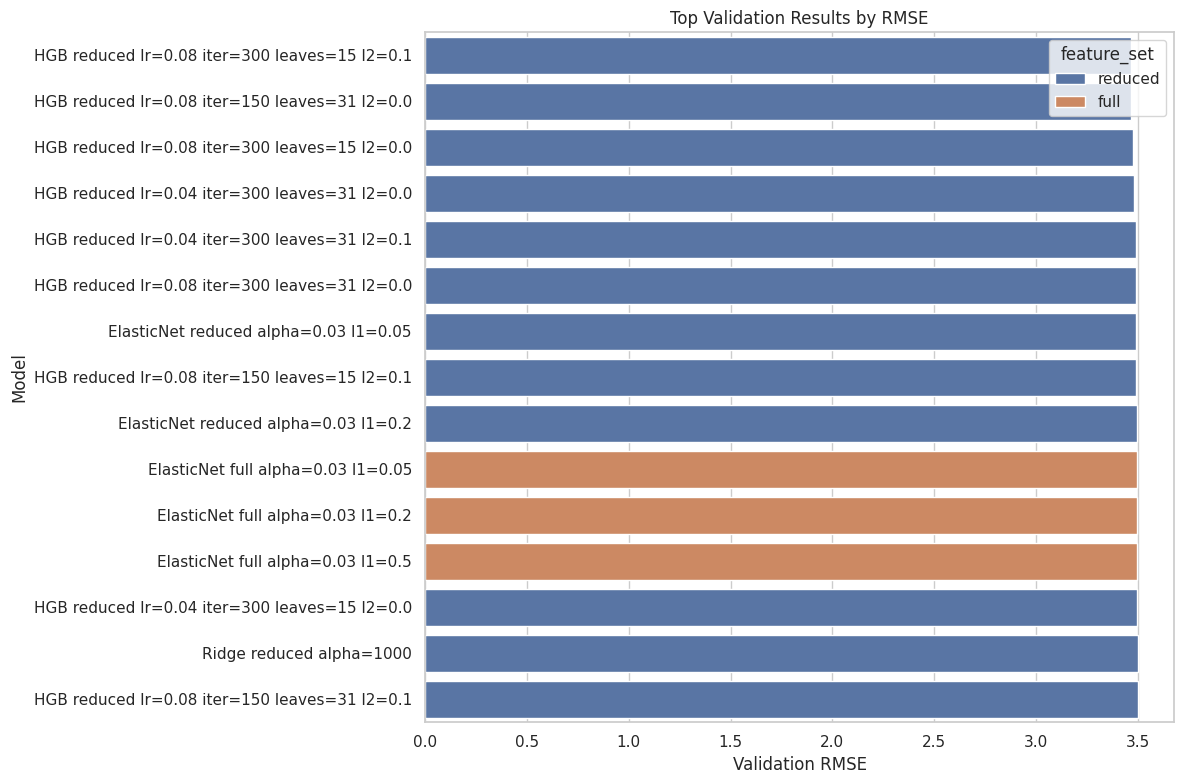

Selected validation winner:


,RMSE,MAE,R2,bias_actual_minus_pred,model,rows,split,feature_set,train_rows,eval_rows,alpha,l1_ratio,l2_regularization,learning_rate,max_iter,max_leaf_nodes
0,3.4685,2.1591,0.8873,0.0316,HGB reduced lr=0.08 iter=300 leaves=15 l2=0.1,NaN,NaN,reduced,"73,548.0000","11,681.0000",NaN,NaN,0.1000,0.0800,300.0000,15.0000


In [12]:
all_validation_results = pd.concat([
    baseline_results[baseline_results['split'] == 'validation'].assign(feature_set='baseline'),
    initial_results,
    ridge_results,
    elastic_results,
    hgb_results,
], ignore_index=True, sort=False)

all_validation_results = all_validation_results.sort_values('RMSE').reset_index(drop=True)
display(all_validation_results[['model', 'feature_set', 'RMSE', 'MAE', 'R2', 'bias_actual_minus_pred']].head(30))

fig, ax = plt.subplots(figsize=(12, 8))
plot_results = all_validation_results.head(15).sort_values('RMSE', ascending=True)
sns.barplot(data=plot_results, y='model', x='RMSE', hue='feature_set', dodge=False, ax=ax)
ax.set_title('Top Validation Results by RMSE')
ax.set_xlabel('Validation RMSE')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

best_row = all_validation_results.iloc[0]
print('Selected validation winner:')
display(best_row.to_frame().T)


In [13]:
# Recover the selected sklearn estimator. Baselines are evaluated separately and are not refit as final sklearn models.
estimator_lookup = {}
estimator_lookup.update({label: est for label, _, est in initial_candidates})
estimator_lookup.update(ridge_estimators)
estimator_lookup.update(elastic_estimators)
estimator_lookup.update(hgb_estimators)

selected_model_name = best_row['model']
selected_feature_set = best_row['feature_set']
selected_estimator = estimator_lookup.get(selected_model_name)

if selected_estimator is None:
    print('The baseline won validation. We will still evaluate the best non-baseline model for comparison.')
    non_baseline_results = all_validation_results[all_validation_results['feature_set'] != 'baseline']
    best_non_baseline = non_baseline_results.iloc[0]
    selected_model_name = best_non_baseline['model']
    selected_feature_set = best_non_baseline['feature_set']
    selected_estimator = estimator_lookup[selected_model_name]
    display(best_non_baseline.to_frame().T)
else:
    print(f'Using selected model: {selected_model_name}')
    print(f'Feature set: {selected_feature_set}')


Using selected model: HGB reduced lr=0.08 iter=300 leaves=15 l2=0.1
Feature set: reduced


## 13. Final Time-Based Test Evaluation

After model selection, the selected model is refit on train + validation years and evaluated once on the future test period. This is the main performance estimate for the report.


In [14]:
train_val_df = pd.concat([splits['train'], splits['validation']], ignore_index=True)
test_df = splits['test'].copy()

final_estimator = clone(selected_estimator)
features = feature_sets[selected_feature_set]['numeric'] + feature_sets[selected_feature_set]['categorical']
final_estimator.fit(train_val_df[features], train_val_df[TARGET])

test_df['final_model_prediction'] = clipped_predictions(final_estimator, test_df[features])
test_df['historical_median_prediction'] = test_df['historical_target_swe_median']
test_df['train_val_mean_prediction'] = train_val_df[TARGET].mean()

final_test_results = pd.DataFrame([
    evaluate_prediction_frame(test_df, 'train_val_mean_prediction', 'Train+validation mean dummy'),
    evaluate_prediction_frame(test_df, 'historical_median_prediction', 'Historical target SWE median'),
    evaluate_prediction_frame(test_df, 'final_model_prediction', selected_model_name),
]).sort_values('RMSE')

final_test_results['RMSE_improvement_vs_baseline'] = (
    final_test_results.loc[final_test_results['model'].eq('Historical target SWE median'), 'RMSE'].iloc[0]
    - final_test_results['RMSE']
)
final_test_results['pct_RMSE_improvement_vs_baseline'] = (
    final_test_results['RMSE_improvement_vs_baseline']
    / final_test_results.loc[final_test_results['model'].eq('Historical target SWE median'), 'RMSE'].iloc[0]
    * 100
)

display(final_test_results[['model', 'RMSE', 'MAE', 'R2', 'bias_actual_minus_pred', 'RMSE_improvement_vs_baseline', 'pct_RMSE_improvement_vs_baseline', 'rows']])


,model,RMSE,MAE,R2,bias_actual_minus_pred,RMSE_improvement_vs_baseline,pct_RMSE_improvement_vs_baseline,rows
2,HGB reduced lr=0.08 iter=300 leaves=15 l2=0.1,3.2837,2.0806,0.9103,-0.4210,2.9038,46.9303,17747
1,Historical target SWE median,6.1875,3.4871,0.6816,0.1377,0.0000,0.0000,17747
0,Train+validation mean dummy,10.9682,8.1690,-0.0005,-0.2510,-4.7807,-77.2636,17747


## 14. Month-Level Evaluation

The overall comparison is the main result, but month-level metrics show whether the model is strong throughout the snow season or only during certain months.


,target_month,rows,final_RMSE,final_MAE,final_R2,baseline_RMSE,baseline_MAE,baseline_R2,RMSE_improvement,pct_RMSE_improvement
0,1,2537,2.7164,1.8520,0.8633,4.8290,3.2684,0.5679,2.1126,43.7482
1,11,2535,1.9142,1.4119,0.3760,2.0573,1.4755,0.2793,0.1431,6.9543
2,12,2543,2.6189,2.0561,0.7174,3.8337,2.7884,0.3943,1.2148,31.6885
3,2,2519,2.1960,1.5763,0.9495,6.0739,3.9118,0.6136,3.8779,63.8456
4,3,2538,3.6384,2.5548,0.9232,8.6816,5.5383,0.5630,5.0432,58.0907
5,4,2539,4.2641,3.0153,0.9107,8.8131,5.1883,0.6186,4.5490,51.6162
6,5,2536,4.6145,2.0927,0.6569,5.9824,2.2397,0.4234,1.3680,22.8664


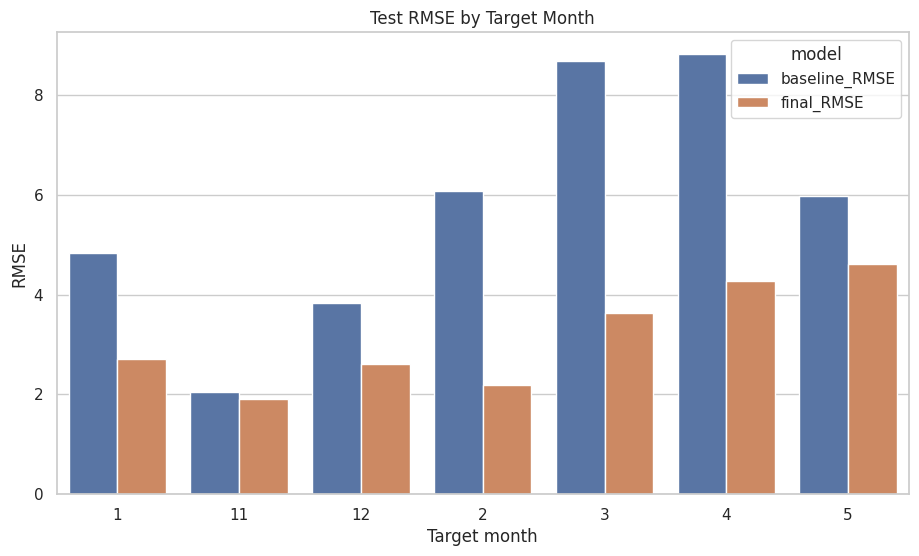

In [15]:
def metrics_by_group(data, prediction_col, group_col):
    rows = []
    for group_value, group_df in data.groupby(group_col):
        metrics = regression_metrics(group_df[TARGET], group_df[prediction_col])
        metrics[group_col] = group_value
        metrics['rows'] = len(group_df)
        rows.append(metrics)
    return pd.DataFrame(rows).sort_values(group_col)

month_eval = metrics_by_group(test_df, 'final_model_prediction', 'target_month')
month_baseline = metrics_by_group(test_df, 'historical_median_prediction', 'target_month')
month_eval = month_eval.rename(columns={'RMSE': 'final_RMSE', 'MAE': 'final_MAE', 'R2': 'final_R2'})
month_baseline = month_baseline.rename(columns={'RMSE': 'baseline_RMSE', 'MAE': 'baseline_MAE', 'R2': 'baseline_R2'})
month_comparison = month_eval[['target_month', 'rows', 'final_RMSE', 'final_MAE', 'final_R2']].merge(
    month_baseline[['target_month', 'baseline_RMSE', 'baseline_MAE', 'baseline_R2']],
    on='target_month',
)
month_comparison['RMSE_improvement'] = month_comparison['baseline_RMSE'] - month_comparison['final_RMSE']
month_comparison['pct_RMSE_improvement'] = month_comparison['RMSE_improvement'] / month_comparison['baseline_RMSE'] * 100

display(month_comparison)

fig, ax = plt.subplots()
month_plot = month_comparison.melt(
    id_vars='target_month',
    value_vars=['baseline_RMSE', 'final_RMSE'],
    var_name='model',
    value_name='RMSE',
)
sns.barplot(data=month_plot, x='target_month', y='RMSE', hue='model', ax=ax)
ax.set_title('Test RMSE by Target Month')
ax.set_xlabel('Target month')
ax.set_ylabel('RMSE')
plt.show()


## 15. Station-Grouped Generalization Test

The station-grouped split holds out entire stations from training. This is harder than the time split because the model must generalize to stations it has never seen. The historical median baseline cannot be fairly computed for unseen stations if a station has no training history, but in this cleansed dataset the feature already exists from preprocessing. We still report it as a reference and interpret station-holdout results cautiously.


In [16]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
groups = df['station_triplet']
train_idx, station_test_idx = next(gss.split(df, groups=groups))
station_train_df = df.iloc[train_idx].copy()
station_test_df = df.iloc[station_test_idx].copy()

station_estimator = clone(selected_estimator)
station_estimator.fit(station_train_df[features], station_train_df[TARGET])

station_test_df['final_model_prediction'] = clipped_predictions(station_estimator, station_test_df[features])
station_test_df['historical_median_prediction'] = station_test_df['historical_target_swe_median']
station_test_df['station_train_mean_prediction'] = station_train_df[TARGET].mean()

station_results = pd.DataFrame([
    evaluate_prediction_frame(station_test_df, 'station_train_mean_prediction', 'Station-train mean dummy'),
    evaluate_prediction_frame(station_test_df, 'historical_median_prediction', 'Historical target SWE median'),
    evaluate_prediction_frame(station_test_df, 'final_model_prediction', selected_model_name),
]).sort_values('RMSE')

display(pd.Series({
    'train_rows': len(station_train_df),
    'test_rows': len(station_test_df),
    'train_stations': station_train_df['station_triplet'].nunique(),
    'test_stations': station_test_df['station_triplet'].nunique(),
    'station_overlap': len(set(station_train_df['station_triplet']).intersection(set(station_test_df['station_triplet']))),
}).to_frame('value'))

display(station_results[['model', 'RMSE', 'MAE', 'R2', 'bias_actual_minus_pred', 'rows']])


,value
train_rows,82414
test_rows,20562
train_stations,688
test_stations,172
station_overlap,0


,model,RMSE,MAE,R2,bias_actual_minus_pred,rows
2,HGB reduced lr=0.08 iter=300 leaves=15 l2=0.1,3.4232,2.0631,0.9247,0.0368,20562
1,Historical target SWE median,7.0589,3.9526,0.6800,-0.3315,20562
0,Station-train mean dummy,12.5092,8.6219,-0.0051,0.8890,20562


## 16. Final Model Diagnostics

The diagnostics below compare predictions and residuals on the future test period. A good model should track the one-to-one line reasonably well, have residuals centered near zero, and avoid systematic month-level bias.


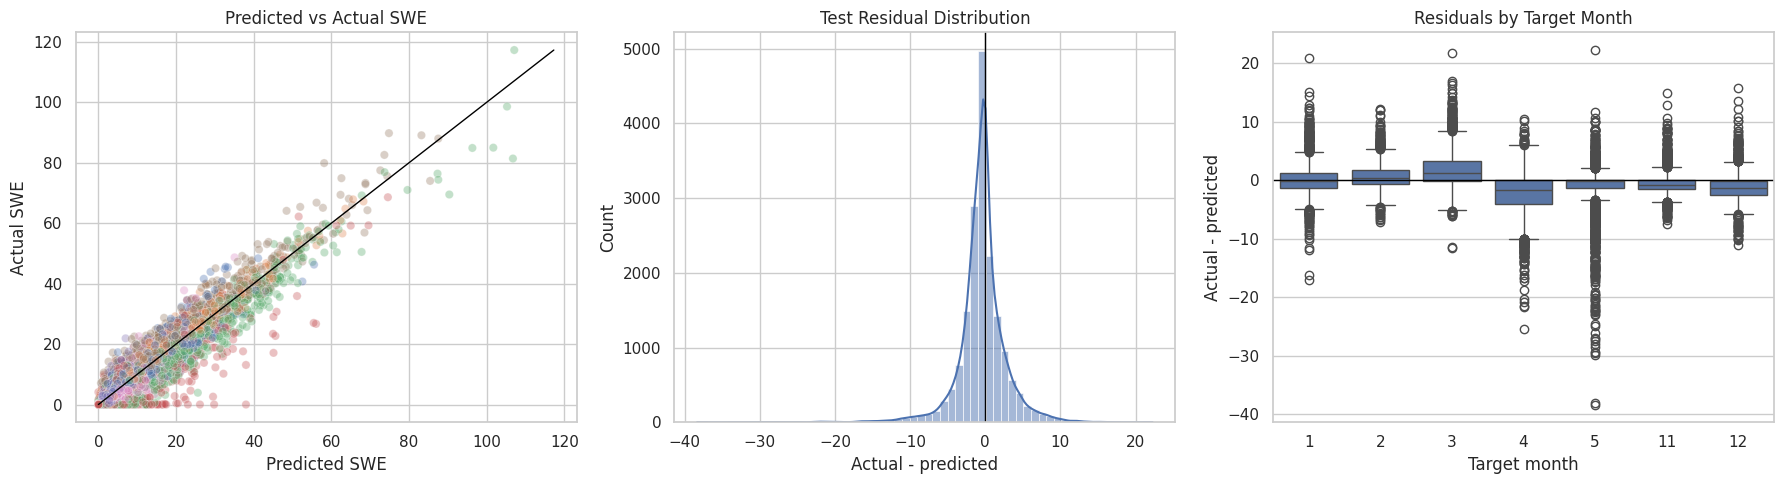

,rows,mean,median,std,p05,p95
target_month,,,,,,
1,2537,0.1374,-0.1854,2.7134,-3.4695,4.9031
11,2535,-0.5726,-0.8302,1.8269,-2.7271,2.7006
12,2543,-1.1823,-1.3741,2.3373,-4.4853,2.9328
2,2519,0.6354,0.3713,2.1024,-2.1797,4.4075
3,2538,1.7996,1.2206,3.1628,-2.3288,7.8448
4,2539,-2.2790,-1.7141,3.6047,-9.0868,2.7347
5,2536,-1.4765,-0.0664,4.3727,-10.0455,2.3879


In [17]:
test_df['residual'] = test_df[TARGET] - test_df['final_model_prediction']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample = test_df.sample(min(10000, len(test_df)), random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x='final_model_prediction', y=TARGET, hue='target_month', alpha=0.35, ax=axes[0], legend=False)
max_val = max(sample['final_model_prediction'].max(), sample[TARGET].max())
axes[0].plot([0, max_val], [0, max_val], color='black', linewidth=1)
axes[0].set_title('Predicted vs Actual SWE')
axes[0].set_xlabel('Predicted SWE')
axes[0].set_ylabel('Actual SWE')

sns.histplot(test_df['residual'], bins=60, kde=True, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Test Residual Distribution')
axes[1].set_xlabel('Actual - predicted')

sns.boxplot(data=test_df, x='target_month', y='residual', ax=axes[2])
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Residuals by Target Month')
axes[2].set_xlabel('Target month')
axes[2].set_ylabel('Actual - predicted')

plt.tight_layout()
plt.show()

residual_summary = (
    test_df.groupby('target_month')['residual']
    .agg(rows='size', mean='mean', median='median', std='std', p05=lambda s: s.quantile(0.05), p95=lambda s: s.quantile(0.95))
)
display(residual_summary)


## 17. Feature Importance / Interpretation

For the selected model, permutation importance estimates how much test RMSE worsens when each raw input feature is shuffled. This is model-agnostic and safer than relying only on raw coefficients when features are correlated.


,feature,rmse_increase_mean,rmse_increase_std
0,current_swe,2.9502,0.0593
5,swe_change_2mo,1.8672,0.0530
21,month_sin,1.6143,0.0554
6,historical_target_swe_median,1.3849,0.0234
22,month_cos,0.6656,0.0183
2,swe_lag_2,0.3836,0.0110
15,TMAX_mean,0.2721,0.0122
18,elevation,0.2432,0.0203
4,swe_change_1mo,0.2384,0.0121
13,TAVG_mean,0.1799,0.0130


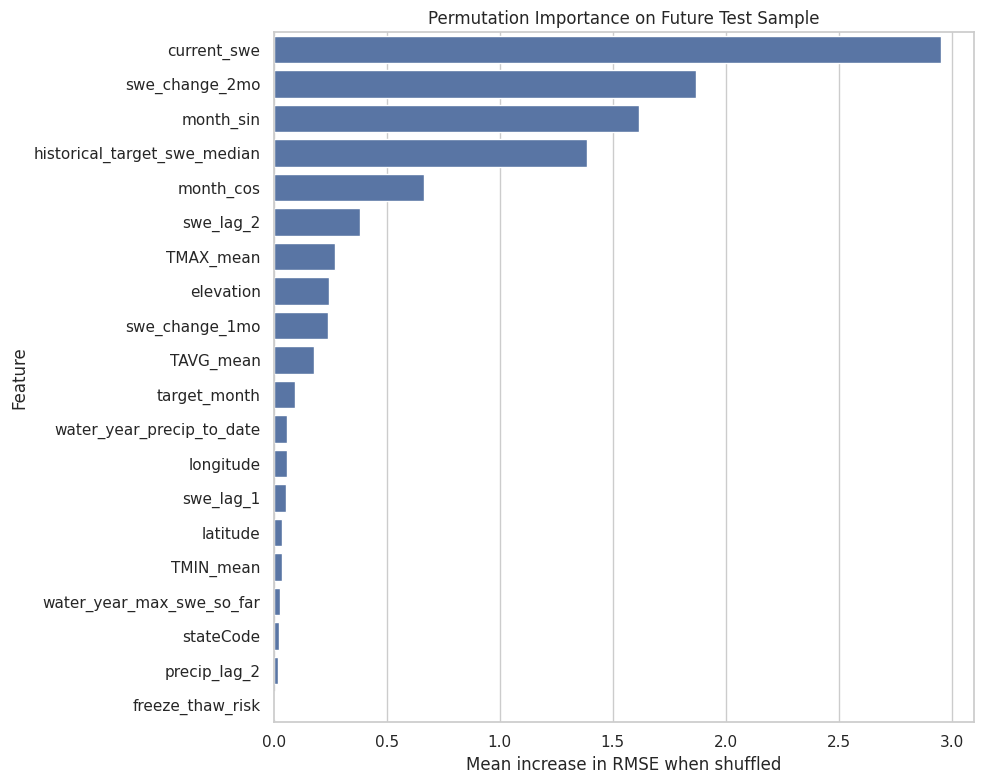

In [18]:
importance_sample = test_df.sample(min(6000, len(test_df)), random_state=RANDOM_STATE)

perm = permutation_importance(
    final_estimator,
    importance_sample[features],
    importance_sample[TARGET],
    scoring='neg_root_mean_squared_error',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance = pd.DataFrame({
    'feature': features,
    'rmse_increase_mean': perm.importances_mean,
    'rmse_increase_std': perm.importances_std,
}).sort_values('rmse_increase_mean', ascending=False)

display(importance.head(25))

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=importance.head(20), y='feature', x='rmse_increase_mean', ax=ax)
ax.set_title('Permutation Importance on Future Test Sample')
ax.set_xlabel('Mean increase in RMSE when shuffled')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


## 18. Report-Ready Model Summary

Use this section as the backbone for the report's model section. It answers what model was proposed, why it was chosen, how features were designed, how optimization was done, and what challenges were encountered.


In [19]:
report_summary = {
    'predictive_task': 'Predict next included target-month SWE for each SNOTEL station-month observation.',
    'primary_metric': 'RMSE',
    'main_validation_design': 'Time-based split: train through 2020, validate on 2021-2022, test on 2023+.',
    'generalization_check': 'Station-grouped split holding out entire stations.',
    'baseline_model': 'historical_target_swe_median',
    'selected_model': selected_model_name,
    'selected_feature_set': selected_feature_set,
    'test_RMSE': final_test_results.loc[final_test_results['model'].eq(selected_model_name), 'RMSE'].iloc[0],
    'baseline_test_RMSE': final_test_results.loc[final_test_results['model'].eq('Historical target SWE median'), 'RMSE'].iloc[0],
    'test_RMSE_improvement_vs_baseline': final_test_results.loc[final_test_results['model'].eq(selected_model_name), 'RMSE_improvement_vs_baseline'].iloc[0],
    'test_pct_RMSE_improvement_vs_baseline': final_test_results.loc[final_test_results['model'].eq(selected_model_name), 'pct_RMSE_improvement_vs_baseline'].iloc[0],
}

display(pd.Series(report_summary).to_frame('value'))

print('Narrative notes:')
print('- Ridge/ElasticNet models were included specifically because EDA showed severe multicollinearity among snowpack variables.')
print('- The reduced feature set tested whether removing redundant snowpack summaries improved stability or RMSE.')
print('- Gradient boosting tested whether nonlinear interactions improved over regularized linear models.')
print('- The historical median baseline is strong because it captures station-specific climatology for each target month.')
print('- Final model selection is based on validation RMSE, with final reporting on the held-out future test period.')


,value
predictive_task,Predict next included target-month SWE for eac...
primary_metric,RMSE
main_validation_design,"Time-based split: train through 2020, validate..."
generalization_check,Station-grouped split holding out entire stati...
baseline_model,historical_target_swe_median
selected_model,HGB reduced lr=0.08 iter=300 leaves=15 l2=0.1
selected_feature_set,reduced
test_RMSE,3.2837
baseline_test_RMSE,6.1875
test_RMSE_improvement_vs_baseline,2.9038


Narrative notes:
- Ridge/ElasticNet models were included specifically because EDA showed severe multicollinearity among snowpack variables.
- The reduced feature set tested whether removing redundant snowpack summaries improved stability or RMSE.
- Gradient boosting tested whether nonlinear interactions improved over regularized linear models.
- The historical median baseline is strong because it captures station-specific climatology for each target month.
- Final model selection is based on validation RMSE, with final reporting on the held-out future test period.
